# K-Means Clustering

In [1]:
# Remember: library imports are ALWAYS at the top of the script, no exceptions!
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from math import ceil

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

## New imports
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans


sns.set()

In [2]:
## Un-comment these if you want to use ydata_profiling

# !pip install -U ydata-profiling
# from ydata_profiling import ProfileReport


## Context
The data we will be using through the pratical classes comes from a small relational database whose schema can be seen below:

![Schema](https://raw.githubusercontent.com/fpontejos/DMDM_2223/main/figures/schema.png "Relation database schema")

## Reading the Data

In [3]:
## Allow Colab to see Google Drive files

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
## Load csv file into a dataframe
## Paste the path here
data_path = "/content/drive/MyDrive/Colab Data/datamining.csv"

df = pd.read_csv(data_path)

In [5]:
## Load csv file into a dataframe
## Alternative location of the csv file

## data_path = "https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/datamining.csv"

## df = pd.read_csv(data_path)

### Make a copy of your original dataset

why?

In [6]:
df_original = df.copy()

### Metadata
- *id* - The unique identifier of the customer
- *age* - The year of birht of the customer
- *income* - The income of the customer
- *frq* - Frequency: number of purchases made by the customer
- *rcn* - Recency: number of days since last customer purchase
- *mnt* - Monetary: amount of € spent by the customer in purchases
- *clothes* - Number of clothes items purchased by the customer
- *kitchen* - Number of kitchen items purchased by the customer
- *small_appliances* - Number of small_appliances items purchased by the customer
- *toys* - Number of toys items purchased by the customer
- *house_keeping* - Number of house_keeping items purchased by the customer
- *dependents* - Binary. Whether or not the customer has dependents
- *per_net_purchase* - Percentage of purchases made online
- *education* - Education level of the customer
- *status* - Marital status of the customer
- *gender* - Gender of the customer
- *description* - Last customer's recommendation description

## Preprocess the Data

Remember what we did in the previous session

In [7]:
# Sometimes it is not obvious that a value is missing
# For example if the value is an empty string

# replace "" by nans
df.replace("", np.nan, inplace=True)

In [8]:
df["dependents"] = df["dependents"].astype("boolean")


In [9]:
# Define metric and non-metric features. Why?
non_metric_features = ["education", "status", "gender", "dependents", "description"]

## This is saying that the metric features are all the other features that are not non-metric
## Need to be careful in case not all columns are to be used as features

# metric_features = df.columns.drop(non_metric_features).to_list()

## Or you can also specify manually
metric_features = ['age',
 'income',
 'frq',
 'rcn',
 'mnt',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase']

### Fill missing values (Data imputation)

How can we fill missing values?


#### Using measures of central tendency

In [10]:
# Creating a copy to apply central tendency measures imputation
df_central = df.copy()

In [11]:
# count of missing values
df_central.isna().sum()

Unnamed: 0            0
age                   0
income               46
frq                   0
rcn                   0
mnt                   0
clothes               0
kitchen               0
small_appliances      0
toys                  0
house_keeping         0
dependents          282
per_net_purchase      0
gender                0
education            47
status              177
description           0
dtype: int64

In [12]:
medians = df_central[metric_features].median()

In [13]:
modes = df_central[non_metric_features].mode().loc[0]

In [14]:
## Fill NaNs using medians and modes

df_central.fillna(medians, inplace=True)
df_central.fillna(modes, inplace=True)

<ipython-input-14-d0340abf7cd5>:4: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df_central.fillna(modes, inplace=True)


In [15]:
df_central.isna().sum()  # checking how many NaNs we still have

Unnamed: 0          0
age                 0
income              0
frq                 0
rcn                 0
mnt                 0
clothes             0
kitchen             0
small_appliances    0
toys                0
house_keeping       0
dependents          0
per_net_purchase    0
gender              0
education           0
status              0
description         0
dtype: int64

In [16]:
df = df_central.copy()

### Outlier removal

In [17]:
def remove_outliers(df, filters):

  df_2 = df[filters]
  print('Percentage of data kept after removing outliers:', 100*(np.round(df_2.shape[0] / df.shape[0], 4)))

  return df_2



In [18]:
# This may vary from session to session, and is prone to varying interpretations.
# A simple example is provided below:

manual_filters = (
    (df['house_keeping']<=50)
    &
    (df['kitchen']<=40)
    &
    (df['toys']<=35)
    &
    (df['education']!='OldSchool')
)

df_1 = remove_outliers(df, manual_filters)

Percentage of data kept after removing outliers: 97.99


In [19]:
# Get the manual filtering version
df = df_1.copy()

In [20]:
# How can we avoid having as many extreme values in 'rcn'?
print((df['rcn']>100).value_counts())

rcn_t = df['rcn'].copy()
rcn_t.loc[rcn_t>100] = 100

df['rcn'] = rcn_t

False    8437
True      380
Name: rcn, dtype: int64


#### What about non-metric features?

In [21]:
# Let's also remove status=Whatever
df.loc[df['status'] == 'Whatever', 'status'] = df['status'].mode()[0]


### Feature Engineering and Feature Selection

In [22]:
df['birth_year'] = df['age']
df['age'] = datetime.now().year - df['birth_year']

df['spent_online'] = (df['per_net_purchase'] / 100) * df['mnt']

#### Redundancy


In [23]:
# Select variables according to their correlations
df.drop(columns=['birth_year', 'age', 'mnt'], inplace=True)

In [24]:
# Updating metric_features
metric_features.append("spent_online")
metric_features.remove("mnt")
metric_features.remove("age")

In [25]:
metric_features

['income',
 'frq',
 'rcn',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase',
 'spent_online']

#### Relevancy
Selecting variables based on the relevancy of each one to the task. Example: remove uncorrelated variables with the target, stepwise regression, use variables for product clustering, use variables for socio-demographic clustering, ...

Variables that aren't correlated with any other variable are often also not relevant. In this case we will not focus on this a lot since we don't have a defined task yet.

### Data Normalization

#### Standard Scaling

In [26]:
df_standard = df.copy()

In [27]:
scaler = StandardScaler()
scaled_feat = scaler.fit_transform(df_standard[metric_features])
df_standard[metric_features] = scaled_feat


In [28]:
df = df_standard.copy()

### One-hot encoding

In [29]:
df_ohc = df.copy()

In [30]:
def get_ohc_df(df, feats):
  # Use OneHotEncoder to encode the categorical features.
  # Get feature names and create a DataFrame
  # with the one-hot encoded categorical features (pass feature names)

  ohc = OneHotEncoder(sparse_output=False, drop="first")
  ohc_feat = ohc.fit_transform(df[feats])
  ohc_feat_names = ohc.get_feature_names_out()
  ohc_df = pd.DataFrame(ohc_feat, index=df.index, columns=ohc_feat_names)

  # Reassigning df to contain ohc variables
  df_ohc = pd.concat([df, ohc_df], axis=1)

  ## Return the df with the one-hot encoded features
  ## Also return the OneHotEncoder model (ohc)
  return df_ohc, ohc

df_ohc, ohc = get_ohc_df(df, non_metric_features)


In [31]:
oh_features = ohc.get_feature_names_out().tolist()
oh_features

['education_2nd Cycle',
 'education_Graduation',
 'education_Master',
 'education_PhD',
 'status_Married',
 'status_Single',
 'status_Together',
 'status_Widow',
 'gender_M',
 'dependents_1.0',
 'description_Kind of OK',
 'description_Meh...',
 'description_OK nice!',
 'description_Take my money!!']

In [32]:
df_ohc.columns

Index(['Unnamed: 0', 'income', 'frq', 'rcn', 'clothes', 'kitchen',
       'small_appliances', 'toys', 'house_keeping', 'dependents',
       'per_net_purchase', 'gender', 'education', 'status', 'description',
       'spent_online', 'education_2nd Cycle', 'education_Graduation',
       'education_Master', 'education_PhD', 'status_Married', 'status_Single',
       'status_Together', 'status_Widow', 'gender_M', 'dependents_1.0',
       'description_Kind of OK', 'description_Meh...', 'description_OK nice!',
       'description_Take my money!!'],
      dtype='object')

In [33]:
df = df_ohc.copy()

### OR... Import preprocessed data


## K-Means Clustering
What is K-Means clustering? How does it work?

https://www.youtube.com/watch?v=5I3Ei69I40s


### How is it computed?

![](https://raw.githubusercontent.com/fpontejos/DM1_2324/main/figures/kmeans.png)

### Characteristics:
- *Number of clusters* need to be set apriori
- One of the *fastest* clustering algorithms
- The results *depend on the initialization* (stochastic)
- Prone to *local optima*
- Favors *convex* (round shape) and *isotropic* (same shape) clusters

### How to apply K-Means clustering?

In [34]:
## What kinds of features can we use?

kmclust = KMeans(n_clusters=8, init='random', n_init=10, random_state=1)

# the fit method
kmclust.fit(df[metric_features])

KMeans(init='random', n_init=10, random_state=1)

In [35]:
# The predict method
# This gives you the cluster label of each row
kmclust.predict(df[metric_features])

array([7, 7, 2, ..., 3, 1, 6], dtype=int32)

In [36]:
# The transform method
# This gives you the distances of each row to each of the cluster centroids

pd.DataFrame(kmclust.transform(df[metric_features]))

,0,1,2,3,4,5,6,7
0,4.627608,2.091147,5.680550,3.999963,3.877371,3.663439,3.253752,1.184378
1,5.869750,3.185506,6.752700,3.639070,4.435324,4.635154,3.622038,1.884755
2,3.357515,4.344899,2.308358,4.573658,4.274194,3.320663,5.694777,5.628838
3,4.547523,2.449992,5.434009,2.384685,3.410615,3.926630,2.170391,2.698425
4,5.014229,2.569042,5.847540,2.657405,3.346812,3.862978,1.460881,1.970433
...,...,...,...,...,...,...,...,...
8812,4.567402,2.978825,5.720084,2.560584,3.687101,3.775657,2.333016,3.037388
8813,5.570950,3.810277,6.304943,2.863496,3.938649,4.512029,1.913372,3.612973
8814,3.485982,3.896274,4.417488,2.001879,3.059649,2.257762,4.188570,4.513415
8815,4.091790,2.407646,4.507732,3.533405,3.235478,2.972588,3.067185,2.577993


### How can we improve the initialization step?

https://www.youtube.com/watch?v=9nKfViAfajY


In [37]:
# Better initialization method and provide more n_init
kmclust = KMeans(n_clusters=8,
                 init='k-means++',  ## notice different initialization algorithm
                 n_init=15,         ## notice different value
                 random_state=1)    ## why set random_state?

kmclust.fit(df[metric_features])
kmclust.predict(df[metric_features])


array([4, 4, 7, ..., 6, 2, 0], dtype=int32)

*init='k-means++'* initializes the centroids to be (generally) distant from each other, leading to probably better results than random initialization. *n_init=K* allows to initialize KMeans K times and pick the best clustering in terms of Inertia. This can been shown in the link below.

**Empirical evaluation of the impact of k-means initialization:**

https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_stability_low_dim_dense.html#sphx-glr-auto-examples-cluster-plot-kmeans-stability-low-dim-dense-py

### How do we find the number of clusters?

**Inertia (within-cluster sum-of-squares distance) Formula:**
$$\sum_{j=0}^{C}\sum_{i=0}^{n_j}(||x_i - \mu_j||^2)$$
, where:

$C$: Set of identified clusters.

$n_j$: Set of observations belonging to cluster $j$.

$x_i$: Observation $i$.

$\mu_j$: Centroid of cluster $j$.

---

*remember SS_w?*

![](https://raw.githubusercontent.com/fpontejos/DM1_2324/main/figures/ssw_ssb.png)

In [38]:
def plot_inertia(df, feats, max_k=10):
  range_clusters = range(1, max_k+1)

  inertia = []
  for n_clus in range_clusters:  # iterate over desired ncluster range
      kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
      kmclust.fit(df[feats])
      inertia.append(kmclust.inertia_)  # save the inertia of the given cluster solution


  # The inertia plot
  plt.figure(figsize=(9,5))
  plt.plot(range_clusters, inertia)
  plt.ylabel("Inertia: SSw")
  plt.xlabel("Number of clusters")
  plt.xticks(range_clusters)
  plt.title("Inertia plot over clusters", size=15)
  plt.show()

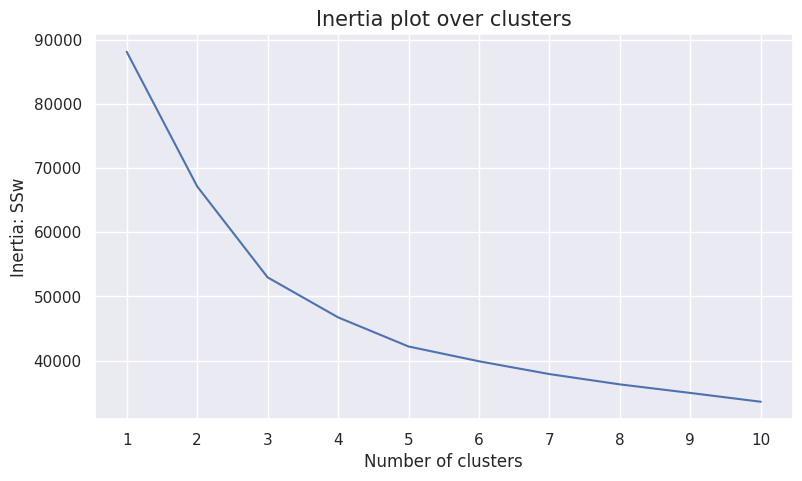

In [39]:
plot_inertia(df, metric_features)

---

**Silhouette Coefficient formula for a single sample:**
$$s = \frac{b - a}{max(a, b)}$$
, where:
- $a$: The mean distance between a sample and all other points in the same cluster.
- $b$: The mean distance between a sample and all other points in the next nearest cluster

---


If $b > a$, then what?

Then the sample is closer to the points in the cluster it is assigned to (compared to the points in the next nearest cluster)

$s$ is positive

---


If $b = a$, then what?

*Then the sample is equally distant to the points in the cluster it is assigned to as well as the points in the next closest cluster*

$s$ is 0

---

If $b < a$, then what?

*Then the sample is closer to the points in the next closest cluster (compared to the points in the same cluster). *

$s$ is negative

---

If the average value of $s$ is high, then what?

**


"Silhouette coefficients (as these values are referred to as) near +1 indicate that the sample is far away from the neighboring clusters. A value of 0 indicates that the sample is on or very close to the decision boundary between two neighboring clusters and negative values indicate that those samples might have been assigned to the wrong cluster."

- https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html





In [40]:
# Adapted from:
# https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

def plot_silhouette_score(df, feats, max_k=10):
  range_clusters = range(2, max_k+1)
  # Skip nclus == 1

  # Storing average silhouette metric
  avg_silhouette = []
  for nclus in range_clusters:
      # Initialize the KMeans object with n_clusters value
      # and a random generator seed for reproducibility.
      kmclust = KMeans(n_clusters=nclus, init='k-means++', n_init=15, random_state=1)
      cluster_labels = kmclust.fit_predict(df[feats])

      # The silhouette_score gives the average value for all the samples.
      # This gives a perspective into the density and separation of the formed clusters
      silhouette_avg = silhouette_score(df[feats], cluster_labels)
      avg_silhouette.append(silhouette_avg)
      print(f"For n_clusters = {nclus}, the average silhouette_score is : {silhouette_avg}")

  # The average silhouette plot
  plt.figure(figsize=(9,5))
  plt.plot(range_clusters, avg_silhouette)
  plt.ylabel("Average silhouette")
  plt.xlabel("Number of clusters")
  plt.xticks(range_clusters)
  plt.title("Average silhouette plot over clusters", size=15)
  plt.show()


For n_clusters = 2, the average silhouette_score is : 0.22169256242414487
For n_clusters = 3, the average silhouette_score is : 0.23707766584584292
For n_clusters = 4, the average silhouette_score is : 0.21036821905415626
For n_clusters = 5, the average silhouette_score is : 0.19514283937028068
For n_clusters = 6, the average silhouette_score is : 0.18736793579734382
For n_clusters = 7, the average silhouette_score is : 0.16983500681630878
For n_clusters = 8, the average silhouette_score is : 0.16670886503251847
For n_clusters = 9, the average silhouette_score is : 0.15495960560993288
For n_clusters = 10, the average silhouette_score is : 0.15066928575504182


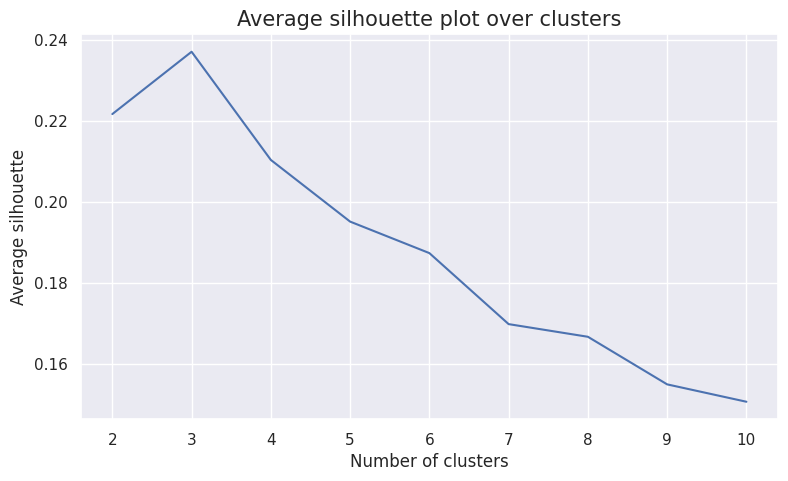

In [41]:
plot_silhouette_score(df, metric_features)

### Final KMeans clustering solution

In [42]:
# final cluster solution
number_clusters = 3
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels = kmclust.fit_predict(df[metric_features])
km_labels

array([2, 2, 0, ..., 1, 2, 2], dtype=int32)

In [43]:
df_km_labeled = pd.concat((df, pd.Series(km_labels, name='km_labels', index=df.index)),
                        axis=1)
df_km_labeled

,Unnamed: 0,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,dependents,...,status_Single,status_Together,status_Widow,gender_M,dependents_1.0,description_Kind of OK,description_Meh...,description_OK nice!,description_Take my money!!,km_labels
0,0,0.743162,1.191605,0.457819,-0.617023,-0.243065,1.216847,0.495837,-0.499274,False,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2
1,1,1.559488,1.100011,-1.535723,0.166160,-0.790228,0.740464,-0.374374,-0.631907,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2
2,2,-1.548542,-0.823463,0.557496,-0.834573,1.672006,-0.371096,-0.809480,2.286023,True,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0
3,3,0.845528,0.550447,-1.402820,0.383710,0.440889,-0.768082,-0.084304,-0.234007,True,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2
4,4,0.782435,1.008417,-0.871209,0.340200,-0.243065,-0.053508,-0.374374,-0.366640,True,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8992,8992,0.618993,0.458853,-1.701851,0.209670,0.167308,-0.132905,0.205767,-0.764540,True,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,2
8993,8993,0.874744,0.733635,-1.701851,0.731791,-0.243065,-0.609288,-0.519409,-0.366640,True,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
8994,8994,-0.455617,-0.731869,-1.535723,0.079139,-0.106274,-0.053508,0.060732,-0.101374,True,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1
8995,8995,-0.596155,0.825229,0.657173,-0.442982,0.577680,0.581670,-0.809480,0.561792,False,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2


In [44]:
## Characterize the clusters
## Just like we did for Hierarchical Clustering

def get_mean_bylabel(df, feats, label_name):
  # Characterizing the clusters
  return df[feats+[label_name]].groupby(label_name).mean()


In [45]:
get_mean_bylabel(df_km_labeled, metric_features, 'km_labels')

,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase,spent_online
km_labels,,,,,,,,,,
0,-1.046753,-0.846839,0.106507,-1.036292,0.812795,0.472976,0.817424,0.835083,0.697810,-0.769234
1,-0.194692,-0.335311,-0.009968,0.891570,-0.578927,-0.635109,-0.585195,-0.563728,0.409679,-0.068841
2,1.052418,1.059654,-0.072209,-0.227987,0.037861,0.371294,0.041556,0.002507,-1.029376,0.686459


### How can we combine the 2 algorithms (K-Means and Hierarchical)?

## Next: DBSCAN and Clustering by Perspectives

### Questions?

## [OPTIONAL] Exercise

To practice your clustering skills, you can do the same exercises on a different dataset.


The Spaceship Titanic Dataset has been loaded for you in the cells below. You can find more information about this dataset from the Kaggle link.


Using this notebook as a guide, try to answer the questions that follow.


---

Addison Howard, Ashley Chow, Ryan Holbrook. (2022). Spaceship Titanic. Kaggle. https://kaggle.com/competitions/spaceship-titanic


In [61]:
titanic_df = pd.read_csv("https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/spaceship_titanic_dataset.csv")


In [62]:
## Keep only the useful features that you identified in the previous exercise

titanic_metric_features = []
titanic_non_metric_features = []


In [63]:
## Don't forget to do the preprocessing steps you performed in the previous exercise


In [64]:
titanic_metric_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
titanic_non_metric_features = ['HomePlanet', 'CryoSleep', 'Destination','VIP', 'Transported']


In [65]:
titanic_df['Name'].replace(np.nan, "NO_NAME", inplace=True)
titanic_df['Cabin'].replace(np.nan, "NO_CABIN", inplace=True)

## Replace missing values using one of the methods shown previously
titanic_central = titanic_df.copy()

titanic_medians = titanic_central[titanic_metric_features].median()
titanic_modes = titanic_central[titanic_non_metric_features].mode().loc[0]

titanic_central.fillna(titanic_medians, inplace=True)
titanic_central.fillna(titanic_modes, inplace=True)

titanic_df = titanic_central.copy()


## Outlier treatment
## Use manual filters
titanic_manual_filters = (
    (titanic_df['RoomService']<=8000)
    &
    (titanic_df['FoodCourt']<=20000)
    &
    (titanic_df['ShoppingMall']<=7500)
    &
    (titanic_df['Spa']<=11000)
    &
    (titanic_df['VRDeck']<=12000)
)

titanic_df_1 = remove_outliers(titanic_df, titanic_manual_filters)
titanic_df = titanic_df_1.copy()


# Use MinMaxScaler to scale the data
titanic_std = titanic_df.copy()
titanic_scaler = MinMaxScaler()
titanic_scaled_feat = titanic_scaler.fit_transform(titanic_std[titanic_metric_features])
titanic_std[titanic_metric_features] = titanic_scaled_feat

titanic_df = titanic_std.copy()

## One-hot encode categorical features
titanic_df_ohc, titanic_ohc = get_ohc_df(titanic_df, titanic_non_metric_features)

titanic_df = titanic_df_ohc.copy()

Percentage of data kept after removing outliers: 99.41


In [66]:
## Perform the KMeans Clustering algorithm on your data
## making sure to use the appropriate hyperparameters such as number of clusters


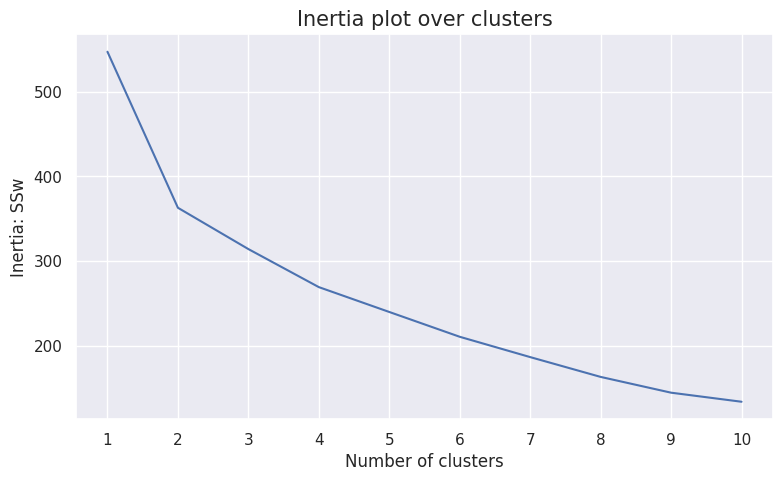

In [67]:
plot_inertia(titanic_df, titanic_metric_features)


For n_clusters = 2, the average silhouette_score is : 0.39641730375254786
For n_clusters = 3, the average silhouette_score is : 0.40780975722758983
For n_clusters = 4, the average silhouette_score is : 0.288222428449683
For n_clusters = 5, the average silhouette_score is : 0.30782088200234786
For n_clusters = 6, the average silhouette_score is : 0.3190651068656161
For n_clusters = 7, the average silhouette_score is : 0.3292544119036876
For n_clusters = 8, the average silhouette_score is : 0.33166981467121787
For n_clusters = 9, the average silhouette_score is : 0.3469472702081319
For n_clusters = 10, the average silhouette_score is : 0.3084272639574717


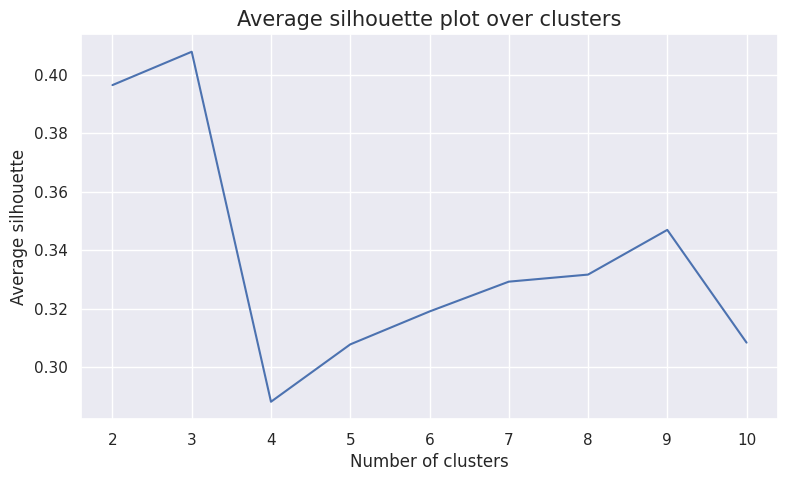

In [68]:
plot_silhouette_score(titanic_df, titanic_metric_features)


In [69]:
# final cluster solution
number_clusters = 3
titanic_km = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
titanic_km_labels = titanic_km.fit_predict(titanic_df[titanic_metric_features])
titanic_km_labels

array([1, 0, 2, ..., 0, 2, 1], dtype=int32)

In [71]:

## Add labels to df
titanic_df['titanic_labels_km'] = titanic_km_labels


In [72]:
## Get cluster means

km_means_titanic = get_mean_bylabel(titanic_df, titanic_metric_features, 'titanic_labels_km')
km_means_titanic.style.background_gradient(axis=0)


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
titanic_labels_km,,,,,,
0,0.254216,0.025273,0.009139,0.022049,0.010784,0.009835
1,0.566676,0.036505,0.017967,0.024617,0.016407,0.014628
2,0.438376,0.019004,0.188039,0.015413,0.212548,0.203336
